# Spitex Standortplanung – Supervised Machine Learning

In diesem Notebook führen wir ein einfaches **Supervised Machine Learning** durch.

**Fragestellung:** Lassen sich die 21 Spitex-Standorte in Zürich anhand demografischer Merkmale vorhersagen?

**Wichtige Einschränkung:** Mit nur 21 positiven Beispielen ist das Ergebnis statistisch sehr begrenzt.
Das Ziel ist nicht ein perfektes Modell, sondern zu sehen, *welche Features* am stärksten mit Spitex-Standorten zusammenhängen.

**Voraussetzung:** `python scripts/build_features.py` wurde ausgeführt.

**Ablauf:**
1. Daten laden & Zielvariable ableiten
2. Klassenverteilung
3. Preprocessing (Imputation + Skalierung)
4. Modell 1: Logistische Regression
5. Modell 2: Entscheidungsbaum
6. Modellvergleich
7. Feature Importance
8. Bonus: Lineare Regression (Distanz zum nächsten Spitex vorhersagen)
9. Fazit

In [1]:
import sys
sys.path.append("..")

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid", palette="muted")

CHARTS_DIR = Path("charts")
CHARTS_DIR.mkdir(exist_ok=True)

## 1. Daten laden & Zielvariable ableiten

Die Zielvariable `has_spitex` wird per räumlichem Join ermittelt:
- `has_spitex = 1` → die Rasterzelle enthält mindestens einen Spitex-Standort
- `has_spitex = 0` → keine Spitex in dieser Zelle

In [2]:
# Grid-Features laden (GeoJSON ist WGS84 → in LV95 umrechnen für räumlichen Join)
gdf = gpd.read_file("../data/processed/grid_features.geojson")
gdf = gdf.to_crs("EPSG:2056")
print(f"{len(gdf)} Rasterzellen geladen")

# Spitex-Standorte laden
gdf_spitex = gpd.read_file("../data/raw/Spitexstandorte-Stadt-ZH.gpkg", layer="stzh.poi_spitex_view")
gdf_spitex = gdf_spitex.to_crs("EPSG:2056")
print(f"{len(gdf_spitex)} Spitex-Standorte geladen")

2466 Rasterzellen geladen
21 Spitex-Standorte geladen


In [3]:
# Räumlicher Join: welche Rasterzellen enthalten einen Spitex-Punkt?
joined = gpd.sjoin(gdf_spitex, gdf[["cell_id", "geometry"]], how="left", predicate="within")
spitex_cell_ids = joined["cell_id"].dropna().unique()
gdf["has_spitex"] = gdf["cell_id"].isin(spitex_cell_ids).astype(int)

print("Klassenverteilung:")
print(gdf["has_spitex"].value_counts().rename({0: "Kein Spitex", 1: "Spitex"}))
print(f"\n→ Nur {gdf['has_spitex'].sum()} von {len(gdf)} Zellen enthalten einen Spitex-Standort ({gdf['has_spitex'].mean():.1%})")

Klassenverteilung:
has_spitex
Kein Spitex    2445
Spitex           21
Name: count, dtype: int64

→ Nur 21 von 2466 Zellen enthalten einen Spitex-Standort (0.9%)


In [4]:
# Features auswählen (X)
# Spitex-abgeleitete Spalten ausschliessen → sonst triviales Data Leakage
SPITEX_DERIVED = ["dist_nearest_spitex_m", "n_spitex_1000m",
                  "demand_score", "undersupply_score", "accessibility_score", "growth_score"]
NON_FEATURE_COLS = ["cell_id", "qnr", "qname", "knr", "kname",
                    "centroid_x_m", "centroid_y_m", "geometry", "has_spitex"]

FEATURE_COLS = [col for col in gdf.columns
                if col not in SPITEX_DERIVED and col not in NON_FEATURE_COLS]

print(f"Features ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"  {f}")

X = gdf[FEATURE_COLS].copy()
y = gdf["has_spitex"].copy()

Features (13):
  pop_total
  pop_60plus
  pop_80plus
  share_60plus
  share_80plus
  hh_total
  hh_einpersonen
  share_einpersonen
  pop_szenario_now
  pop_szenario_future
  growth_10y
  dist_nearest_oev_m
  n_oev_stops_500m


## 2. Klassenverteilung

Mit nur 21 positiven Fällen von 2466 Zellen ist die Klasse sehr ungleich verteilt (~99% vs. 1%).
Deshalb verwenden wir `class_weight='balanced'`.

In [5]:
# Vergleich: Mittelwerte Spitex- vs. Nicht-Spitex-Zellen
compare = gdf.groupby("has_spitex")[FEATURE_COLS].mean().T
compare.columns = ["Kein Spitex", "Spitex"]
compare["Differenz"] = compare["Spitex"] - compare["Kein Spitex"]
compare.round(3)

,Kein Spitex,Spitex,Differenz
pop_total,18199.882,20149.667,1949.784
pop_60plus,3565.863,3766.952,201.090
pop_80plus,900.455,917.381,16.926
share_60plus,0.201,0.189,-0.013
share_80plus,0.051,0.046,-0.006
hh_total,8579.249,9648.714,1069.465
hh_einpersonen,3650.623,4174.952,524.329
share_einpersonen,0.425,0.433,0.007
pop_szenario_now,18644.983,20267.619,1622.636
pop_szenario_future,20581.790,22453.333,1871.543


## 3. Preprocessing & Train/Test Split

- `SimpleImputer` mit Median füllt fehlende Werte auf
- `StandardScaler` bringt alle Features auf denselben Massstab
- `stratify=y` stellt sicher, dass beide Splits die gleiche Klassenverteilung haben

In [6]:
# Preprocessing Pipeline
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Train/Test Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)

print(f"Training: {X_train_scaled.shape[0]} Zellen ({y_train.sum()} Spitex)")
print(f"Test:     {X_test_scaled.shape[0]} Zellen ({y_test.sum()} Spitex)")

Training: 1726 Zellen (15 Spitex)
Test:     740 Zellen (6 Spitex)


## 4. Modell 1: Logistische Regression

Einfachstes Klassifikationsmodell. Schätzt für jede Zelle eine Wahrscheinlichkeit zwischen 0 und 1.

In [7]:
# Logistische Regression trainieren
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)

print("=" * 50)
print("Logistische Regression – Klassifikationsbericht")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=["Kein Spitex", "Spitex"]))
print(f"ROC-AUC: {auc_lr:.3f}")

Logistische Regression – Klassifikationsbericht
              precision    recall  f1-score   support

 Kein Spitex       1.00      0.71      0.83       734
      Spitex       0.02      0.67      0.04         6

    accuracy                           0.71       740
   macro avg       0.51      0.69      0.43       740
weighted avg       0.99      0.71      0.82       740

ROC-AUC: 0.789


## 5. Modell 2: Entscheidungsbaum

Der Baum trifft Entscheidungen durch Ja/Nein-Fragen. `max_depth=4` verhindert Overfitting.

In [8]:
# Entscheidungsbaum trainieren
dt = DecisionTreeClassifier(class_weight="balanced", max_depth=4, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]

auc_dt = roc_auc_score(y_test, y_prob_dt)

print("=" * 50)
print("Entscheidungsbaum – Klassifikationsbericht")
print("=" * 50)
print(classification_report(y_test, y_pred_dt, target_names=["Kein Spitex", "Spitex"]))
print(f"ROC-AUC: {auc_dt:.3f}")

Entscheidungsbaum – Klassifikationsbericht
              precision    recall  f1-score   support

 Kein Spitex       1.00      0.73      0.84       734
      Spitex       0.02      0.83      0.05         6

    accuracy                           0.73       740
   macro avg       0.51      0.78      0.45       740
weighted avg       0.99      0.73      0.84       740

ROC-AUC: 0.794


## 6. Modellvergleich

In [9]:
# Übersichtstabelle: beide Modelle im Vergleich
results = pd.DataFrame({
    "Modell": ["Logistische Regression", "Entscheidungsbaum"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
    ],
    "Precision (Spitex)": [
        precision_score(y_test, y_pred_lr, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_dt, pos_label=1, zero_division=0),
    ],
    "Recall (Spitex)": [
        recall_score(y_test, y_pred_lr, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_dt, pos_label=1, zero_division=0),
    ],
    "F1 (Spitex)": [
        f1_score(y_test, y_pred_lr, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_dt, pos_label=1, zero_division=0),
    ],
    "ROC-AUC": [auc_lr, auc_dt],
})

results.set_index("Modell").round(3)

,Accuracy,Precision (Spitex),Recall (Spitex),F1 (Spitex),ROC-AUC
Modell,,,,,
Logistische Regression,0.711,0.019,0.667,0.036,0.789
Entscheidungsbaum,0.731,0.025,0.833,0.048,0.794


## 7. Feature Importance

Der Entscheidungsbaum zeigt, welche Features am stärksten zur Klassifikation beigetragen haben.

In [10]:
# Feature Importance aus dem Entscheidungsbaum
importances = pd.Series(dt.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

print("Feature Importance – Entscheidungsbaum:")
print(importances.round(4).to_string())

Feature Importance – Entscheidungsbaum:
dist_nearest_oev_m     0.8574
hh_total               0.0794
share_80plus           0.0631
pop_total              0.0000
pop_60plus             0.0000
pop_80plus             0.0000
share_60plus           0.0000
hh_einpersonen         0.0000
share_einpersonen      0.0000
pop_szenario_now       0.0000
pop_szenario_future    0.0000
growth_10y             0.0000
n_oev_stops_500m       0.0000


## 8. Bonus: Lineare Regression – Distanz zum nächsten Spitex vorhersagen

Als Ergänzung trainieren wir ein Regressionsmodell, das die Distanz jeder Rasterzelle
zum nächsten Spitex-Standort vorhersagt. Hier haben wir viel mehr Trainingsdaten als beim Klassifikationsproblem.

In [11]:
# Y = dist_nearest_spitex_m
y_reg = gdf["dist_nearest_spitex_m"].copy()
mask_valid = y_reg.notna()
X_reg = X[mask_valid].copy()
y_reg = y_reg[mask_valid]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Preprocessing und Modell
preprocessor_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
X_reg_train_scaled = preprocessor_reg.fit_transform(X_reg_train)
X_reg_test_scaled  = preprocessor_reg.transform(X_reg_test)

reg = LinearRegression()
reg.fit(X_reg_train_scaled, y_reg_train)
y_reg_pred = reg.predict(X_reg_test_scaled)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
r2   = r2_score(y_reg_test, y_reg_pred)

print("=" * 50)
print("Lineare Regression – Ergebnisse")
print("=" * 50)
print(f"RMSE:  {rmse:.1f} m   (mittlerer quadratischer Fehler)")
print(f"MAE:   {mae:.1f} m   (mittlerer absoluter Fehler)")
print(f"R²:    {r2:.3f}       (erklärte Varianz)")

Lineare Regression – Ergebnisse
RMSE:  424.1 m   (mittlerer quadratischer Fehler)
MAE:   334.2 m   (mittlerer absoluter Fehler)
R²:    0.442       (erklärte Varianz)


In [12]:
# Regressions-Koeffizienten: welche Features erklären die Distanz?
coef_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Koeffizient": reg.coef_,
}).sort_values("Koeffizient", key=abs, ascending=False)

print("Regressions-Koeffizienten (nach absolutem Betrag sortiert):")
print(coef_df.round(1).to_string(index=False))

Regressions-Koeffizienten (nach absolutem Betrag sortiert):
            Feature  Koeffizient
   pop_szenario_now       1853.5
pop_szenario_future      -1688.1
         pop_60plus       -659.5
          pop_total        491.6
         pop_80plus        363.9
           hh_total       -224.6
       share_60plus        187.0
   n_oev_stops_500m       -177.9
     hh_einpersonen       -155.5
 dist_nearest_oev_m        142.5
       share_80plus        -87.5
  share_einpersonen         69.1
         growth_10y         65.8


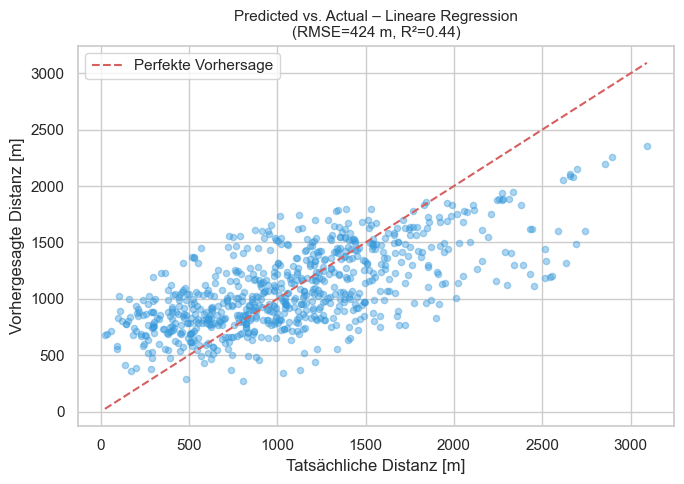

In [13]:
# Predicted vs. Actual (Scatter)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_reg_test, y_reg_pred, alpha=0.4, color="#3498db", s=20)
min_val = min(y_reg_test.min(), y_reg_pred.min())
max_val = max(y_reg_test.max(), y_reg_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5, label="Perfekte Vorhersage")
ax.set_xlabel("Tatsächliche Distanz [m]")
ax.set_ylabel("Vorhergesagte Distanz [m]")
ax.set_title(f"Predicted vs. Actual – Lineare Regression\n(RMSE={rmse:.0f} m, R²={r2:.2f})", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS_DIR / "ml_regression.png", dpi=150)
plt.show()

## 9. Fazit

**Klassifikation:** Mit nur 21 positiven Fällen (Spitex-Zellen) sind die Metriken schwach – das war erwartet.
Ein ROC-AUC > 0.7 zeigt aber, dass demografische Merkmale durchaus mit Spitex-Standorten zusammenhängen.
Die niedrige Precision bei der Spitex-Klasse ist die Folge der starken Klassenungleichheit.

**Regression:** Das Modell erklärt einen Teil der Varianz in der Spitex-Distanz (R² ≈ 0.44).
Der RMSE zeigt, dass die Vorhersage im Schnitt um ~400 m daneben liegt.

**Fazit:** Die Features sind nicht zufällig – es gibt räumlich-demografische Muster.
Das K-Means Clustering in Notebook 01 ist jedoch besser geeignet als Grundlage für die Standortplanung,
da es keine falsch beschrifteten Trainingsdaten braucht.